# Réalisation du plan d'expérience de l'algorithme Tabu Search

Ce plan d'expérience suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

## Définition des paramètres globaux

Nous allons réaliser l'étude statistiques sur les paramètres suivants:
- $N= \{10, 12, 15, 17, 20, 22, 25, 30\}$ : nombre de sommets
- $i= 50$ : nombre d'itérations par instance

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux

### Résultats

Chaque algorithme doit avoir en sortie: 
- le meilleur coût des itération
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimun et le maximum
- graphiques:
    - Trajectoire
    - influence de chaque paramètre (Heatmap à double entrée (type github)) -> tendance générale
    - Distance à la borne (`gap`)
- Meilleur paramètres

In [39]:
import sys

import numpy as np
import networkx as nx

sys.path.insert(0, "../../")
sys.path.insert(0, "../")

from graph_generator import generate_graph
from src.algorithms.tabu_search import resolve_by_tabu_search


### Paramètres globaux et génération des instances

- `N_VALUES` : tailles de graphe étudiées
- `NB_SEEDS` : nombre d'instances (seed distinct) par taille — pour itérer sur les mêmes graphes
- `NB_ITERATIONS` : nombre d'itérations de l'algorithme par instance

In [40]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 10
NB_ITERATIONS: int = 50


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances


### Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [41]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference


### Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [42]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")


N= 10 | 10 instances | ref min=8.10 max=18.52
N= 12 | 10 instances | ref min=8.10 max=20.10
N= 15 | 10 instances | ref min=7.65 max=17.25
N= 17 | 10 instances | ref min=7.05 max=16.80
N= 20 | 10 instances | ref min=7.58 max=16.87
N= 22 | 10 instances | ref min=5.40 max=15.07
N= 25 | 10 instances | ref min=6.38 max=15.90
N= 30 | 10 instances | ref min=7.65 max=12.30


## Étude de trajectoire

On exécute `resolve_by_tabu_search` sur une instance de référence (N=20, seed=0) en enregistrant le meilleur coût à chaque itération pour visualiser la convergence de l'algorithme.

Paramètres utilisés :
- `n_iterations` : nombre d'itérations de la recherche tabou
- `tabu_tenure` : durée (en itérations) pendant laquelle un swap est interdit

In [43]:
def _apply_swap(tour: list[int], i: int, j: int) -> list[int]:
    """Return a new tour with positions i and j swapped."""
    new_tour: list[int] = tour[:]
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour

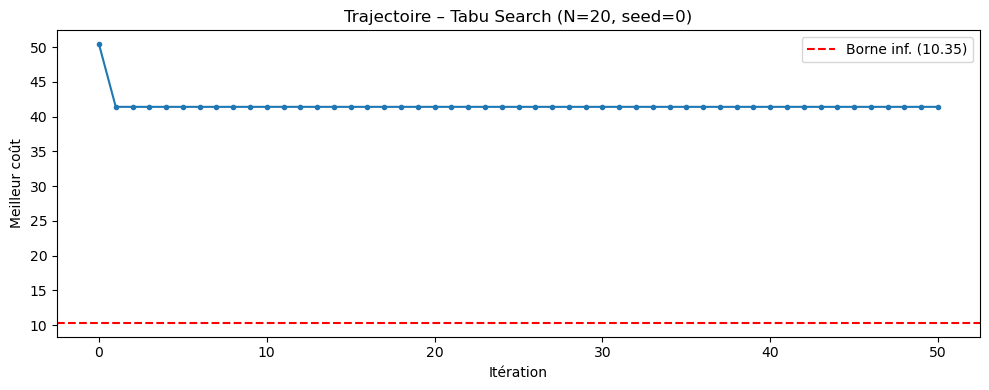

In [44]:
import matplotlib.pyplot as plt
from helper import build_greedy_tour, closed_tour_cost, is_tour_feasible


def tabu_search_trajectory(
    graph: nx.Graph,
    n_iterations: int = NB_ITERATIONS,
    tabu_tenure: int | None = None,
) -> list[float]:
    """Exécute la recherche tabou et retourne la trajectoire du meilleur coût par itération."""
    node_count: int = graph.number_of_nodes()
    if tabu_tenure is None:
        tabu_tenure = max(7, node_count // 5)

    current_tour: list[int] = build_greedy_tour(graph)
    current_cost: float = closed_tour_cost(graph, current_tour)
    best_cost: float = current_cost
    tabu_list: dict[frozenset, int] = {}
    trajectory: list[float] = [best_cost]

    n: int = len(current_tour)
    for iteration in range(n_iterations):
        best_candidate = None
        best_candidate_cost = float("inf")
        best_move = None

        for i in range(n):
            for j in range(i + 1, n):
                candidate = _apply_swap(current_tour, i, j)
                if not is_tour_feasible(graph, candidate):
                    continue
                cost = closed_tour_cost(graph, candidate)
                move_key = frozenset({current_tour[i], current_tour[j]})
                is_tabu = tabu_list.get(move_key, 0) > iteration
                if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                    best_candidate = candidate
                    best_candidate_cost = cost
                    best_move = move_key

        if best_candidate is not None:
            current_tour = best_candidate
            current_cost = best_candidate_cost
            if best_move is not None:
                tabu_list[best_move] = iteration + tabu_tenure
            if current_cost < best_cost:
                best_cost = current_cost

        trajectory.append(best_cost)

    return trajectory


# Instance de référence : N=20, seed=0
_, ref_graph, ref_lb = instances[20][0]
traj = tabu_search_trajectory(ref_graph, n_iterations=NB_ITERATIONS)

plt.figure(figsize=(10, 4))
plt.plot(traj, marker="o", markersize=3, linewidth=1.5)
plt.axhline(ref_lb, color="red", linestyle="--", label=f"Borne inf. ({ref_lb:.2f})")
plt.xlabel("Itération")
plt.ylabel("Meilleur coût")
plt.title("Trajectoire – Tabu Search (N=20, seed=0)")
plt.legend()
plt.tight_layout()
plt.show()


## Étude de l'influence des paramètres

On fait varier les deux paramètres propres à la recherche tabou :
- `n_iterations` $\in \{25, 50, 100, 200\}$
- `tabu_tenure` $\in \{3, 5, 7, 10, 15\}$

Pour chaque combinaison, on calcule le gap moyen sur toutes les instances (toutes tailles, tous seeds).
Le résultat est affiché sous forme de heatmap (type GitHub).

n_iter=  25 | tenure=  3 | gap moyen=338.67%
n_iter=  25 | tenure=  5 | gap moyen=333.38%
n_iter=  25 | tenure=  7 | gap moyen=334.03%
n_iter=  25 | tenure= 10 | gap moyen=337.31%
n_iter=  25 | tenure= 15 | gap moyen=338.80%
n_iter=  50 | tenure=  3 | gap moyen=338.22%
n_iter=  50 | tenure=  5 | gap moyen=328.74%
n_iter=  50 | tenure=  7 | gap moyen=329.42%
n_iter=  50 | tenure= 10 | gap moyen=330.38%
n_iter=  50 | tenure= 15 | gap moyen=332.34%
n_iter= 100 | tenure=  3 | gap moyen=337.72%
n_iter= 100 | tenure=  5 | gap moyen=324.01%
n_iter= 100 | tenure=  7 | gap moyen=324.29%
n_iter= 100 | tenure= 10 | gap moyen=322.77%
n_iter= 100 | tenure= 15 | gap moyen=328.02%
n_iter= 200 | tenure=  3 | gap moyen=337.72%
n_iter= 200 | tenure=  5 | gap moyen=323.29%
n_iter= 200 | tenure=  7 | gap moyen=318.83%
n_iter= 200 | tenure= 10 | gap moyen=317.06%
n_iter= 200 | tenure= 15 | gap moyen=322.62%


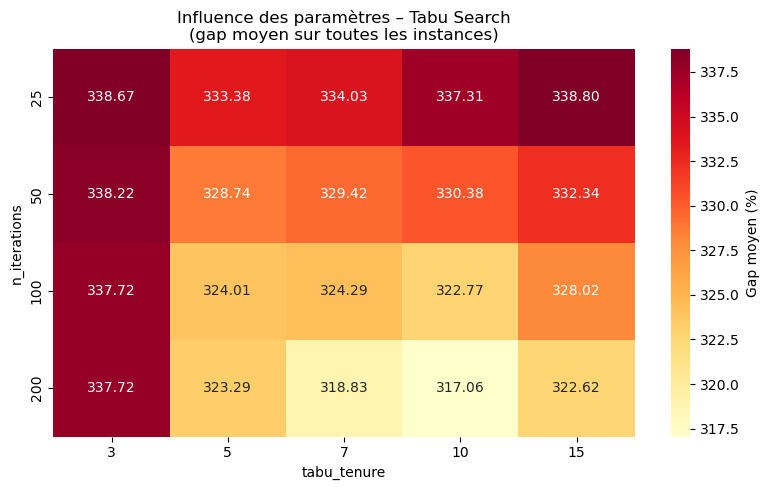

In [45]:
import itertools
import pandas as pd
import seaborn as sns

N_ITER_VALUES: list[int] = [25, 50, 100, 200]
TENURE_VALUES: list[int] = [3, 5, 7, 10, 15]

# Résultats : (n_iterations, tabu_tenure) -> gap moyen
results: dict[tuple[int, int], list[float]] = {}

for n_iter, tenure in itertools.product(N_ITER_VALUES, TENURE_VALUES):
    gaps: list[float] = []
    for n in N_VALUES:
        for seed, graph, ref in instances[n]:
            _, cost = resolve_by_tabu_search(graph, n_iterations=n_iter, tabu_tenure=tenure)
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
    results[(n_iter, tenure)] = gaps
    print(f"n_iter={n_iter:4d} | tenure={tenure:3d} | gap moyen={np.mean(gaps):.2f}%")

# Construction du DataFrame pour la heatmap
mean_gaps = {
    (n_iter, tenure): np.mean(gaps)
    for (n_iter, tenure), gaps in results.items()
}
heatmap_data = pd.DataFrame(
    index=N_ITER_VALUES,
    columns=TENURE_VALUES,
    data=[
        [mean_gaps[(n_iter, tenure)] for tenure in TENURE_VALUES]
        for n_iter in N_ITER_VALUES
    ],
    dtype=float,
)
heatmap_data.index.name = "n_iterations"
heatmap_data.columns.name = "tabu_tenure"

plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "Gap moyen (%)"},
)
plt.title("Influence des paramètres – Tabu Search\n(gap moyen sur toutes les instances)")
plt.tight_layout()
plt.show()


## Distance à la borne (gap) par taille de graphe

On exécute la recherche tabou avec les paramètres par défaut (`n_iterations=50`, `tabu_tenure=max(7, N//5)`) sur toutes les instances et on trace le gap en fonction de N.

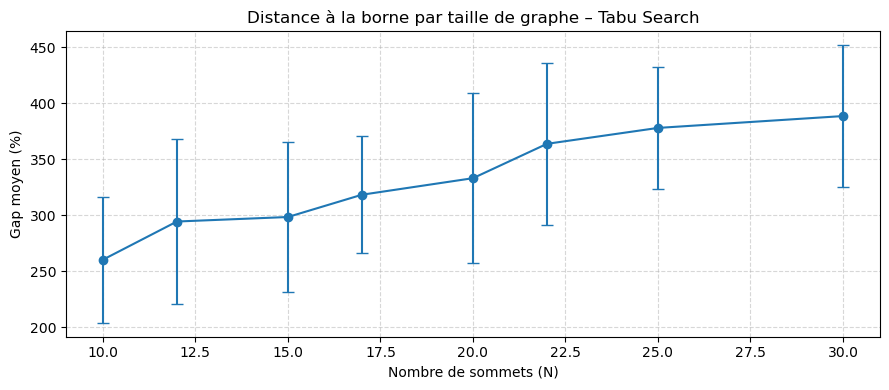

In [46]:
gap_by_n: dict[int, list[float]] = {}

for n in N_VALUES:
    gaps: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_tabu_search(graph, n_iterations=NB_ITERATIONS)
        gap = compute_gap(cost, ref)
        if not np.isnan(gap):
            gaps.append(gap)
    gap_by_n[n] = gaps

means = [np.mean(gap_by_n[n]) for n in N_VALUES]
stds  = [np.std(gap_by_n[n])  for n in N_VALUES]

plt.figure(figsize=(9, 4))
plt.errorbar(N_VALUES, means, yerr=stds, marker="o", capsize=4, linewidth=1.5)
plt.xlabel("Nombre de sommets (N)")
plt.ylabel("Gap moyen (%)")
plt.title("Distance à la borne par taille de graphe – Tabu Search")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


## Statistiques descriptives

Tableau récapitulatif : meilleur coût, moyenne, médiane, écart-type, min et max — par taille de graphe.

In [47]:
rows: list[dict] = []
for n in N_VALUES:
    costs: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_tabu_search(graph, n_iterations=NB_ITERATIONS)
        costs.append(cost)
    rows.append({
        "N": n,
        "Meilleur": np.min(costs),
        "Moyenne": np.mean(costs),
        "Médiane": np.median(costs),
        "Écart-type": np.std(costs),
        "Min": np.min(costs),
        "Max": np.max(costs),
        "Gap moyen (%)": np.mean([compute_gap(c, ref) for (_, __, ref), c in zip(instances[n], costs)]),
    })

stats_df = pd.DataFrame(rows).set_index("N")
stats_df.round(3)


,Meilleur,Moyenne,Médiane,Écart-type,Min,Max,Gap moyen (%)
N,,,,,,,
10,31.80,41.060,39.600,6.291,31.80,52.50,260.361
12,37.35,47.700,41.625,11.775,37.35,71.70,294.462
15,29.25,43.820,44.400,8.478,29.25,55.50,298.489
17,29.25,45.470,41.725,10.509,29.25,63.60,318.384
20,31.80,48.330,46.500,11.452,31.80,69.60,333.155
22,25.20,47.770,50.625,9.548,25.20,57.60,363.842
25,33.75,51.770,51.375,10.963,33.75,71.55,378.047
30,40.80,50.235,50.250,4.407,40.80,56.25,388.638


## Meilleurs paramètres

On identifie la combinaison `(n_iterations, tabu_tenure)` qui minimise le gap moyen sur l'ensemble des instances.

In [48]:
best_params = min(mean_gaps, key=mean_gaps.get)
best_gap    = mean_gaps[best_params]

print(f"Meilleurs paramètres :")
print(f"  n_iterations = {best_params[0]}")
print(f"  tabu_tenure  = {best_params[1]}")
print(f"  Gap moyen    = {best_gap:.2f}%")


Meilleurs paramètres :
  n_iterations = 200
  tabu_tenure  = 10
  Gap moyen    = 317.06%
